## Task 1: Predicting Bike Rental Demand

##### 1. Load the dataset.

In [147]:
import pandas as pd
import numpy as np

df = pd.read_csv('FloridaBikeRentals.csv')

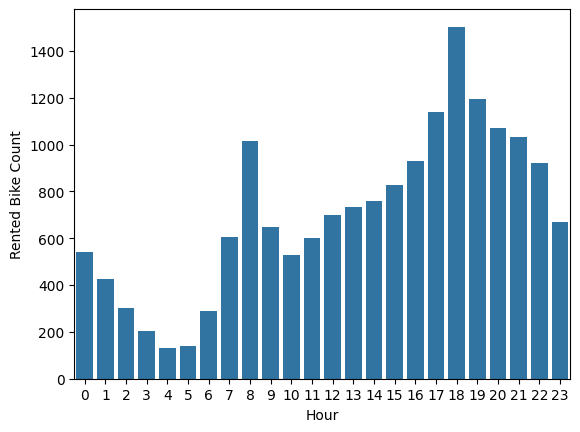

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

avgs = df.groupby('Hour')['Rented Bike Count'].mean()
sns.barplot(data=avgs)
plt.show()

##### 2. Check for null values in any columns and handle the missing values.

In [149]:
df.isna().sum()

Date                        0
Rented Bike Count           0
Hour                        0
Temperature(C)              0
Humidity(%)                 0
Wind speed (m/s)            0
Visibility (10m)            0
Dew point temperature(C)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
dtype: int64

There are no missing values.

##### 3. Convert Date columns to Date format and extract day, month, day of week, and weekdays/weekend from date column.

In [150]:
df.Date = pd.to_datetime(df.Date, format="%d/%m/%Y")  # Convert date column to datetime type
df['Day'] = df.Date.dt.day  # Day of the month, 1 - 31
df['Month'] = df.Date.dt.month  # Month number, 1 - 12
df['Day of Week'] = df.Date.dt.day_of_week  # Assigns values 0 - 6 where 0 = Monday and 6 = Sunday
df['Is Weekend'] = df['Day of Week'] // 5  # 5 and 6 (Saturday and Sunday) are marked as 1, every other day as 0


* "Day" column was added with values from 1-31 for the day of the month.
* Month column was added with values from 1-12 for month of the year.
* "Day of week" column was added with values 0-6 for day of the week.
    * 0 = Monday, 1 = Tuesday, ... 6 = Sunday
* "Is weekend" column was added with 0 for weekdays (Monday through Friday) and 1 for weekends (Saturday and Sunday)

##### 4. Check correlation of features using heatmap.

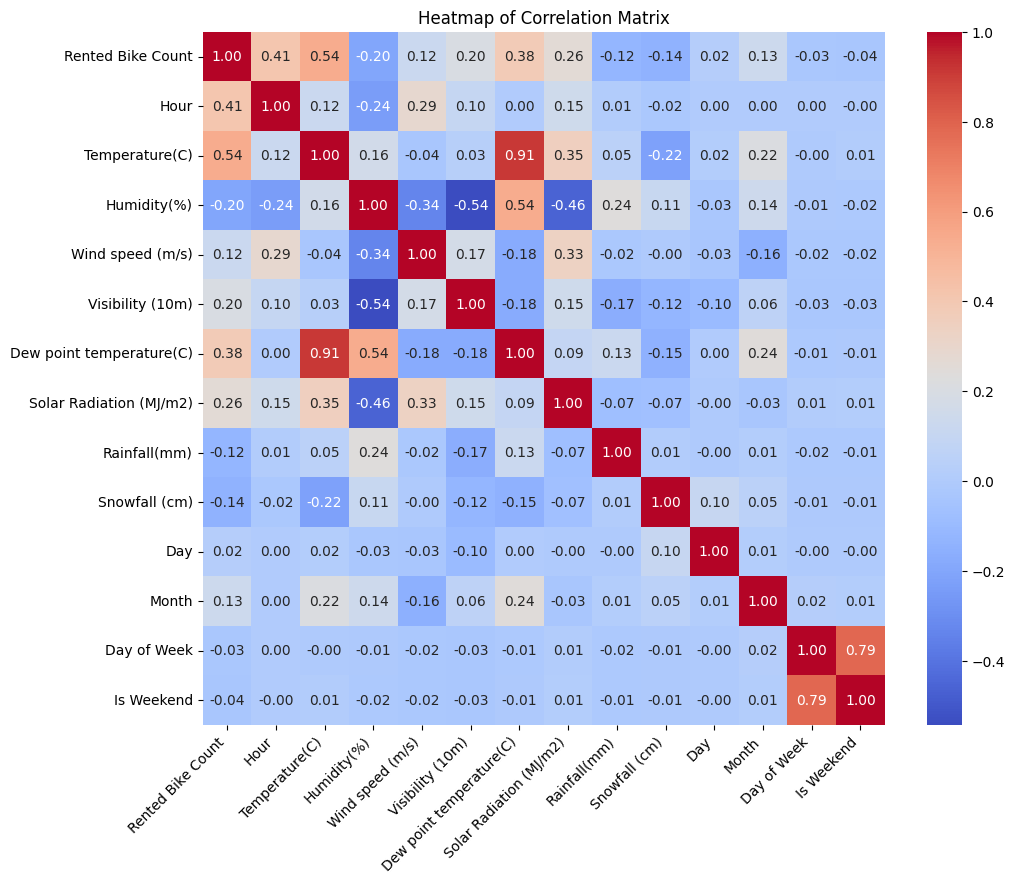

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(11,9))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Correlation Matrix')
plt.xticks(rotation=45, ha="right")
plt.show()

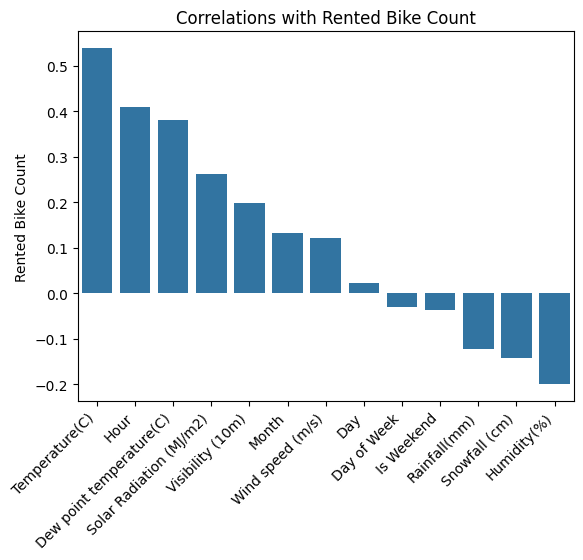

In [163]:
correlations = correlation_matrix['Rented Bike Count'].sort_values(ascending=False)[1:]
sns.barplot(data=correlations)
plt.xticks(rotation=45, ha="right")
plt.title('Correlations with Rented Bike Count')
plt.show()

"Rented Bike Counts" has a notable correlation with a few columns as seen in the bar plot above:
- 0.54 with Temperature
- 0.41 with Hour
- 0.38 with Dew point temperature
- 0.26 with Solar radiation

In general, weather and time of day columns seem to have a noticeable impact on amount of bikes rented.

##### 5. Plot the distribution plot of Rented Bike Count.

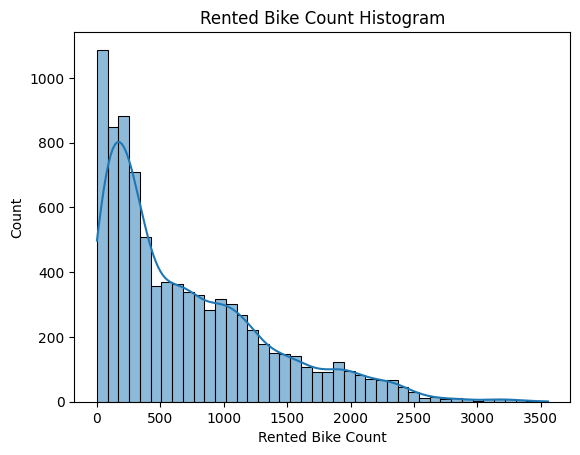

In [153]:
sns.histplot(df['Rented Bike Count'], kde=True)
plt.title("Rented Bike Count Histogram")
plt.show()

The distribution is right skewed. Many days have little to no bike rentals, and fewer days have many rentals.

##### 6. Plot the histogram of all numerical features.

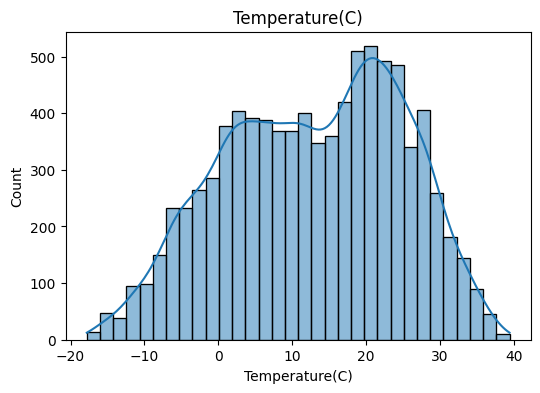

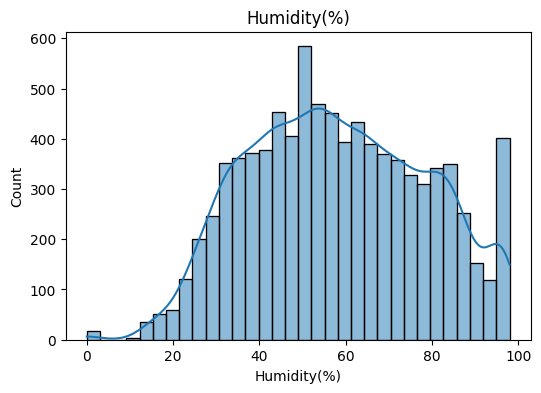

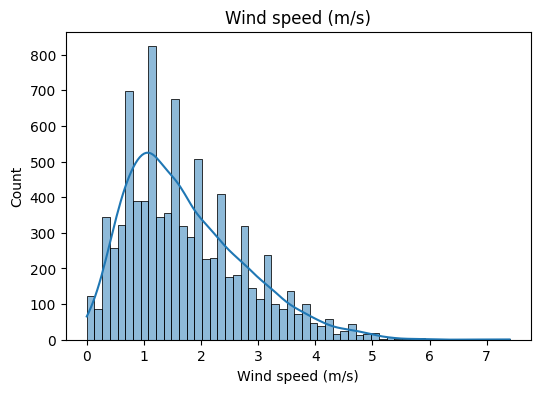

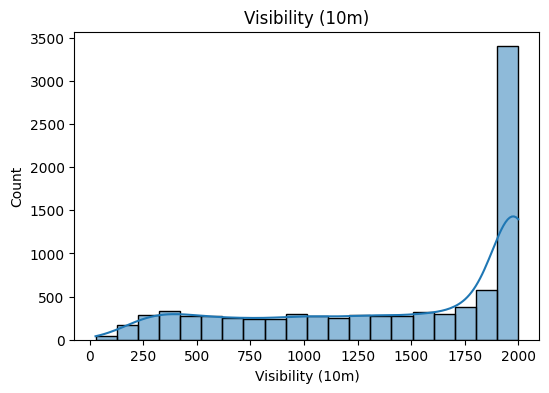

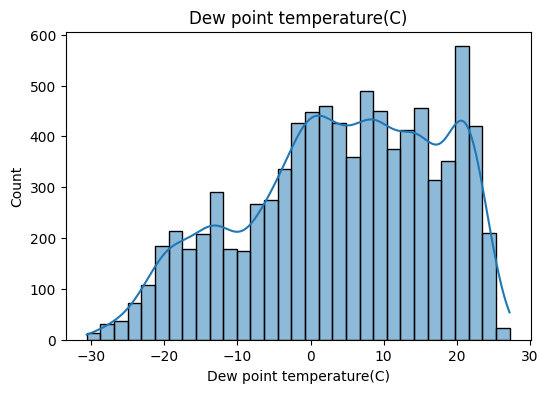

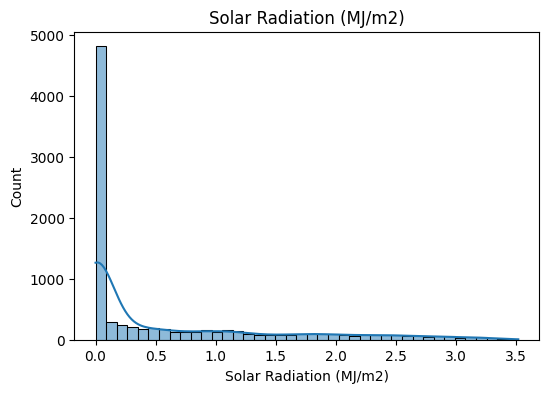

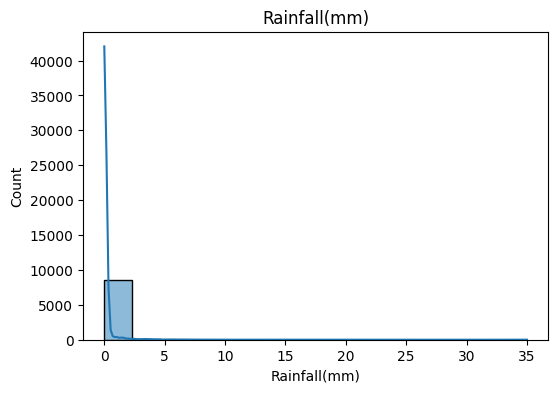

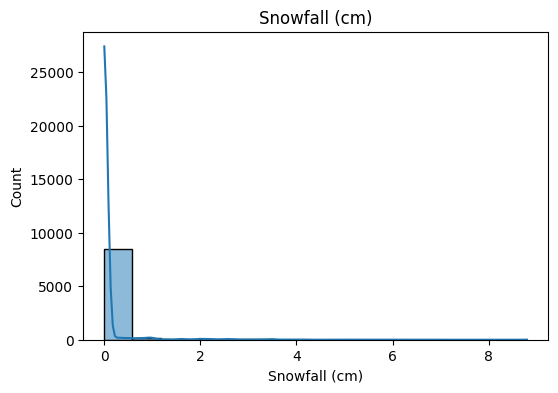

In [154]:
num_cols = df.select_dtypes(include='number').drop(columns=['Rented Bike Count', 'Hour', 'Is Weekend', 'Month', 'Day of Week', 'Day'])

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(str(col))
    plt.show()

##### 7. Plot the box plot of Rented Bike Count against all the categorical features (Hint: Categorical features on X-axis and Rented Bike Count on Y-axis).

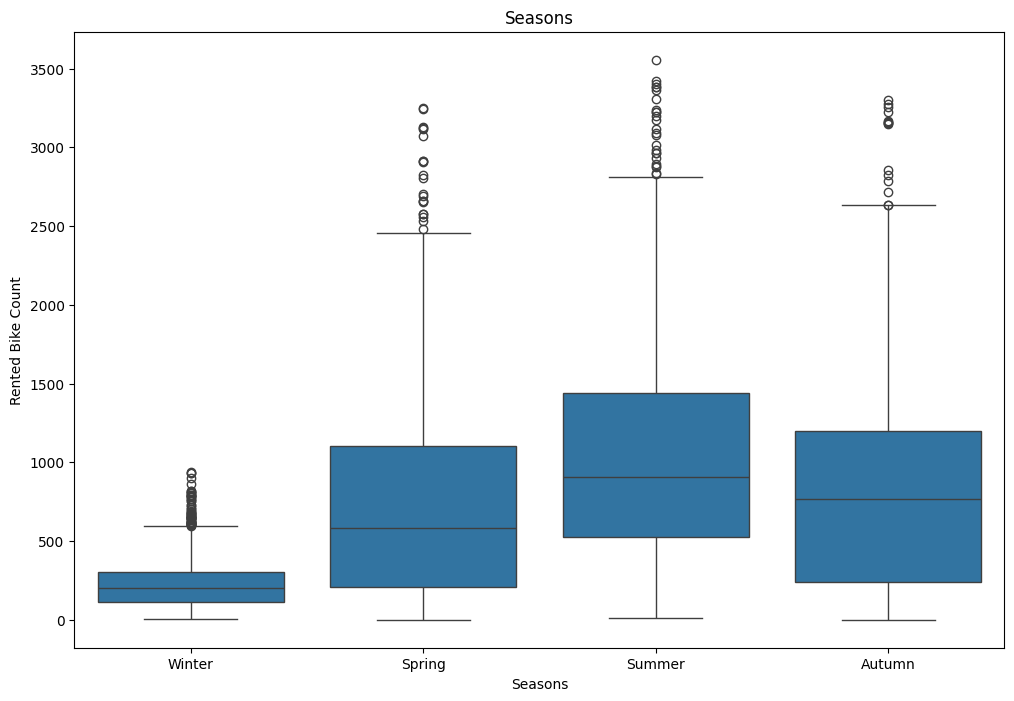

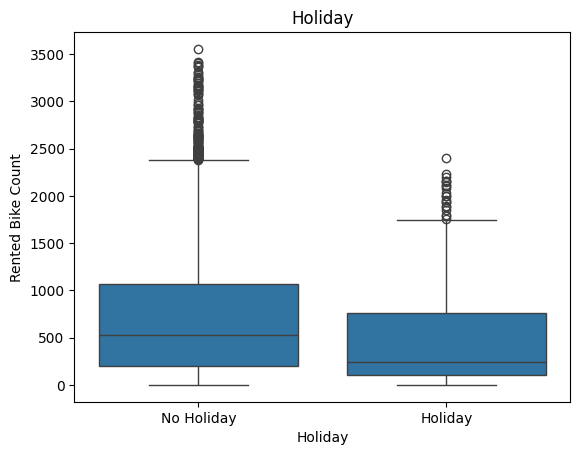

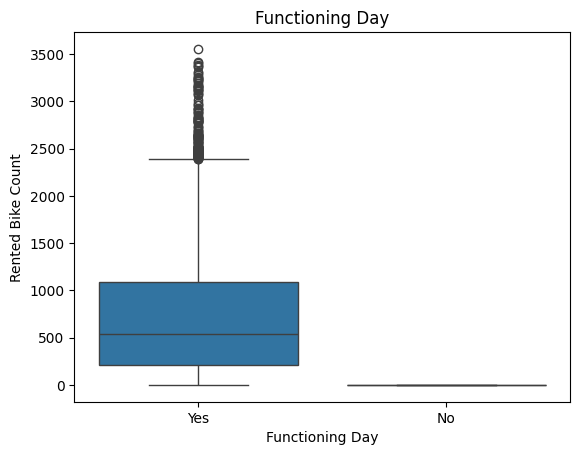

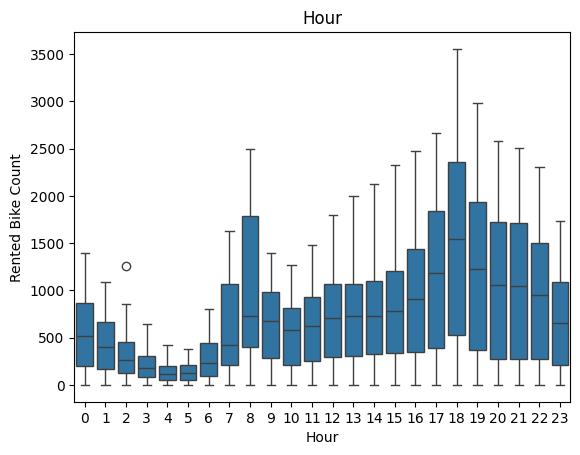

In [165]:
plt.figure(figsize=(12,8))

categoricals = df.select_dtypes(include='object')

for col in categoricals:
    sns.boxplot(data=df, y='Rented Bike Count', x=col)
    plt.title(col)
    plt.show()

sns.boxplot(data=df, y='Rented Bike Count', x='Hour')
plt.title('Hour')
plt.show()

##### 8. Plot the Seaborn catplot of Rented Bike Count against features like Hour, Holiday, Rainfall (mm), Snowfall (cm), weekdays, weekend, and give your inferences.

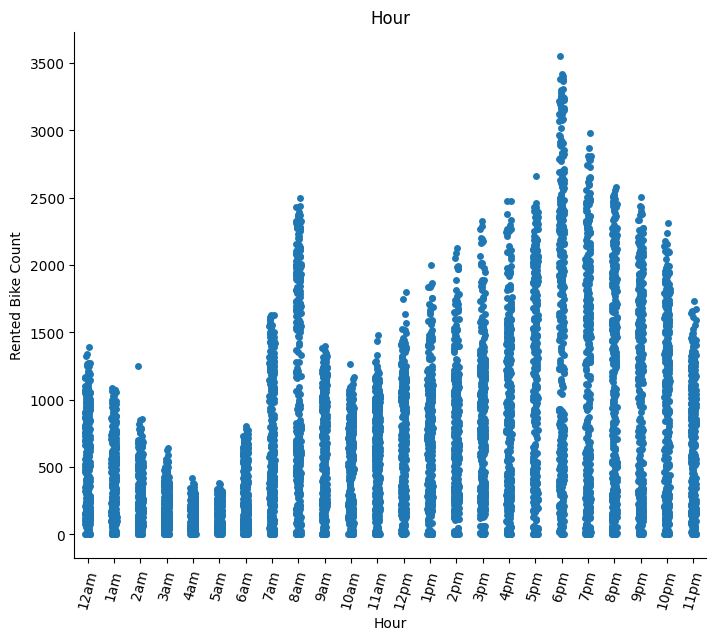

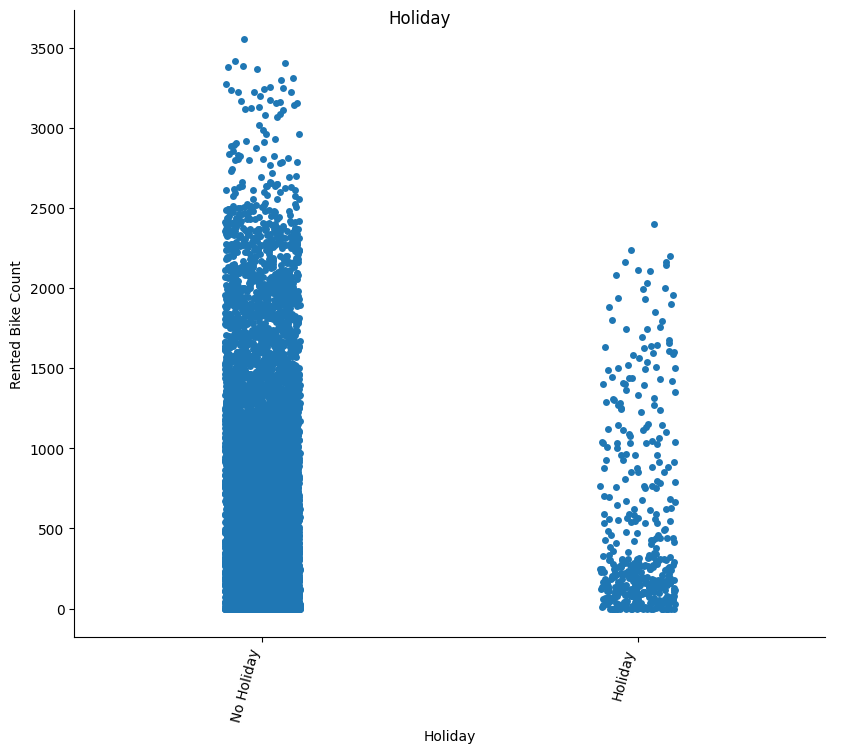

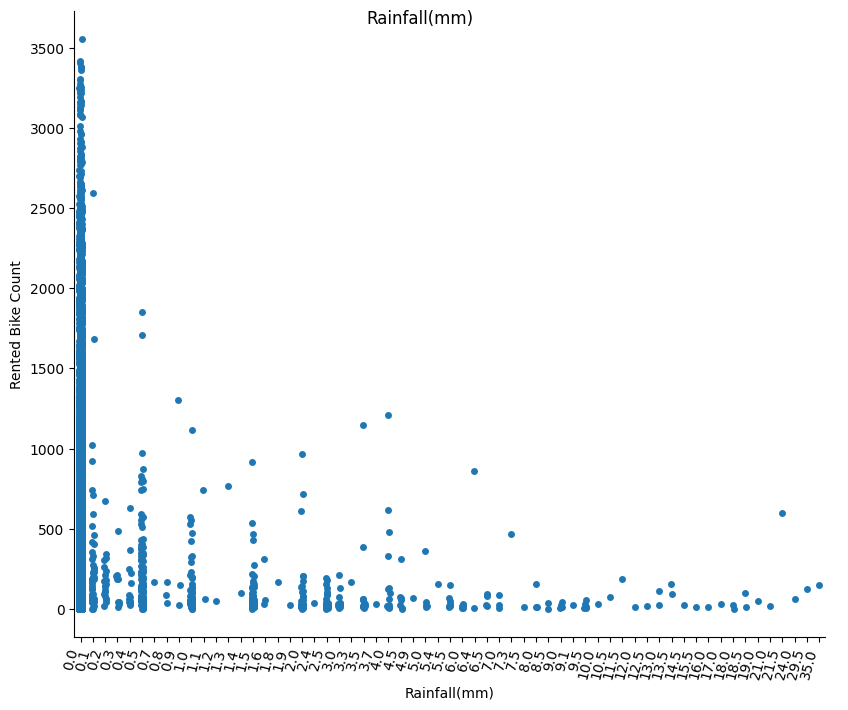

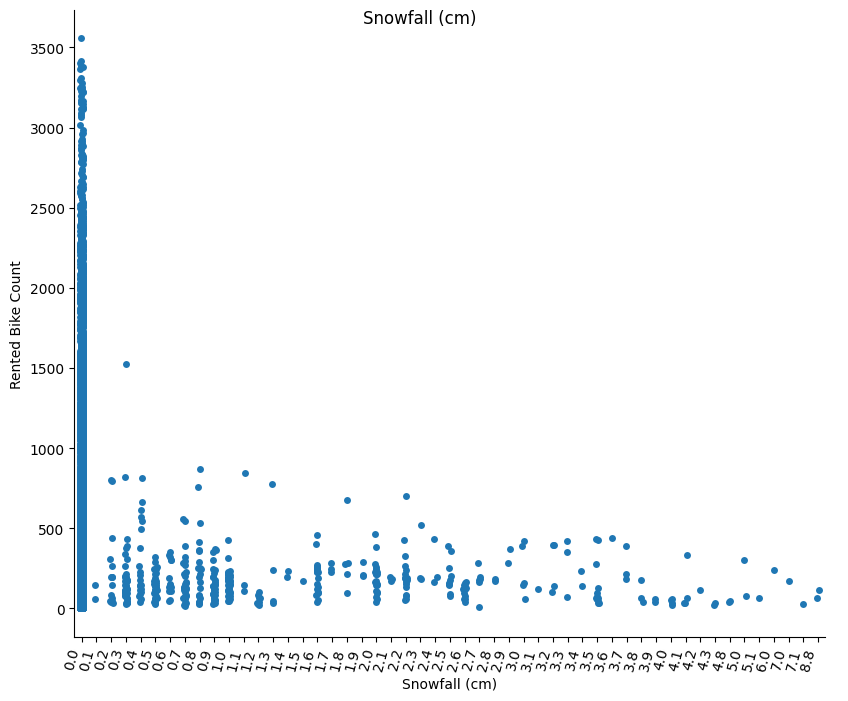

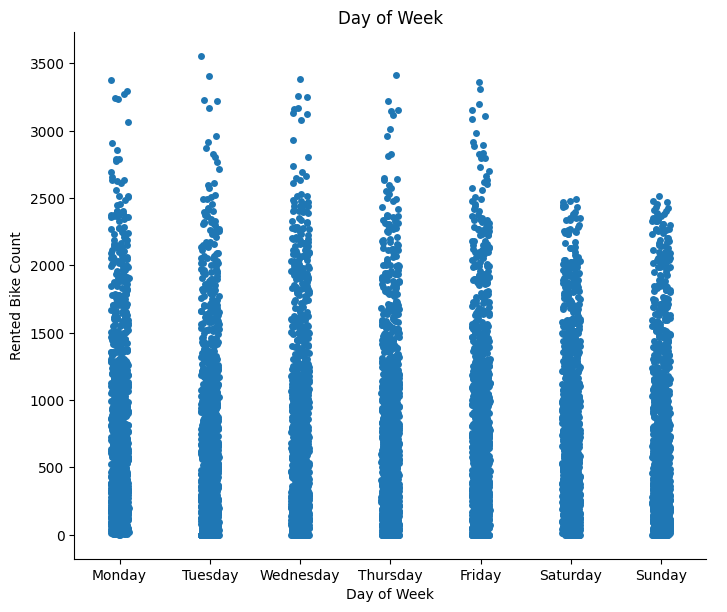

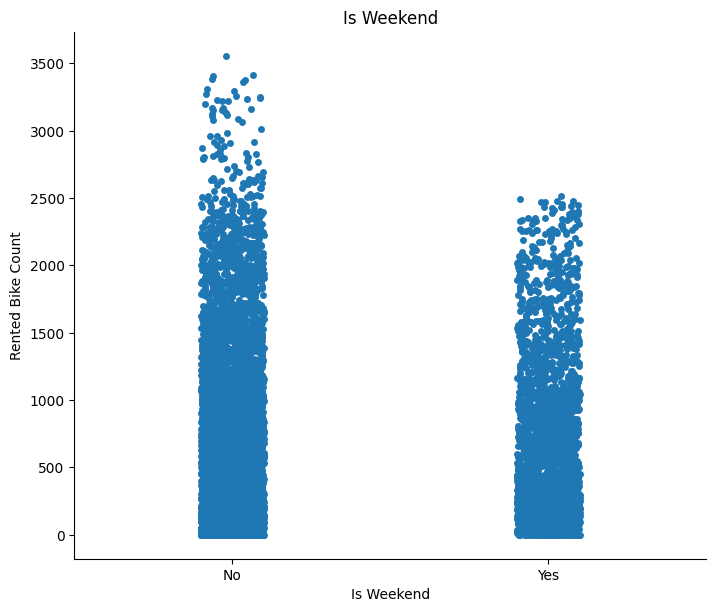

In [ ]:
# "Hour" graph
g = sns.catplot(data=df, x='Hour', y='Rented Bike Count', height=6, aspect=1.2)
plt.xticks(list(range(24)), ['12am'] + [f'{hr}am' for hr in range(1, 12)] + ['12pm'] + [f'{hr}pm' for hr in range(1, 12)], rotation=75)
plt.title("Hour")
plt.show()

# Holiday, Rainfall, and Snowfall graphs
cols = ['Holiday', 'Rainfall(mm)', 'Snowfall (cm)']
for col in cols:
    g = sns.catplot(data=df, x=col, y='Rented Bike Count', height=7, aspect=1.2)
    g.set_xticklabels(rotation=75, ha="right")
    g.fig.suptitle(col)
    plt.show()

# "Day of week" graph
g = sns.catplot(data=df, x='Day of Week', y='Rented Bike Count', height=6, aspect=1.2)
plt.xticks([0, 1, 2, 3, 4, 5, 6], ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Day of Week")
plt.show()

# "Is Weekend" graph
g = sns.catplot(data=df, x='Is Weekend', y='Rented Bike Count', height=6, aspect=1.2)
plt.xticks([0, 1], ["No", "Yes"])
plt.title("Is Weekend")
plt.show()

Inferences:
- Hour:
    - 6 pm is the most popular hour for renting bikes, probably from people leaving work.
    - Bike rentals steadily increase from 10 am to 6pm and then drop until 4 am.
    - There a peak in rentals at 8 am, probably from people going to work.

- Holiday:
    - Holiday days have significantly less bike rentals

- Rainfall:
    - On days with 0 rainfall, there are significantly higher bike rentals
    - Rainfall significantly reduces bike rentals. The more rain there is, the less bike are rented, but even 0.1 mm of rainfall significantly reduces rentals.

- Snowfall:
    - Same conclusion as rainfall.

- Day of Week and Is Weekend:
    - Business days have roughly the same rentals, and weekend days have less rentals.

##### 9. Encode the categorical features into numerical features (Hint: use get_dummies()).

In [166]:
categoricals = ['Seasons', 'Day of Week']

# Replace the given columns with their dummies version, with first dummy column dropped
encoded_df = pd.get_dummies(df, columns=categoricals, drop_first=True, dtype=int) 
encoded_df = encoded_df.rename(columns={
    "Day of Week_1": "Day_of_Week_Tuesday",
    "Day of Week_2": "Day_of_Week_Wednesday",
    "Day of Week_3": "Day_of_Week_Thursday",
    "Day of Week_4": "Day_of_Week_Friday",
    "Day of Week_5": "Day_of_Week_Saturday",
    "Day of Week_6": "Day_of_Week_Sunday",
})

# In the boolean columns, convert string values to 0 or 1 values
encoded_df['Holiday'] = encoded_df['Holiday'].map({'No Holiday': 0, 'Holiday': 1})
encoded_df["Functioning Day"] = encoded_df["Functioning Day"].map({"No": 0, "Yes": 1})


##### 10. Identify the target variable and split the dataset into train and test with a ratio of 80:20 and random state 1.

In [167]:
from sklearn.model_selection import train_test_split

X = encoded_df.drop(columns=['Rented Bike Count', 'Date'])
y = encoded_df['Rented Bike Count']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

##### 11. Perform Standard Scaling of the train dataset.

In [168]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

##### 12. Perform Linear Regression, Lasso Regression, and Ridge Regression to predict the bike count required each hour and compare the results.

In [169]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train model
lin_reg = LinearRegression()
lin_reg.fit(X_train_sc, y_train)

# Run model
lin_pred = lin_reg.predict(X_test_sc)

# MSE
lin_mse = mean_squared_error(y_test, lin_pred)
print(f"Test MSE: {lin_mse:,.0f}")

# RMSE
lin_rmse = np.sqrt(lin_mse)
print(f"Test RMSE: {lin_rmse:,.0f}")

# R squared
lin_r2 = r2_score(y_test, lin_pred)
print(f"Test R-squared: {lin_r2:.5f}")


Test MSE: 185,591
Test RMSE: 431
Test R-squared: 0.55094


In [170]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1, max_iter=10000)
lasso_model.fit(X_train_sc, y_train)

lasso_pred = lasso_model.predict(X_test_sc)

# MSE
lasso_mse = mean_squared_error(y_test, lasso_pred)
print(f"Test MSE: {lasso_mse:,.0f}")

# RMSE
lasso_rmse = np.sqrt(lasso_mse)
print(f"Test RMSE: {lasso_rmse:,.0f}")

# R squared
lasso_r2 = r2_score(y_test, lasso_pred)
print(f"Test R-squared: {lasso_r2:.5f}")

Test MSE: 185,389
Test RMSE: 431
Test R-squared: 0.55143


In [171]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=100)
ridge_model.fit(X_train_sc, y_train)

ridge_pred = ridge_model.predict(X_test_sc)

# MSE
ridge_mse = mean_squared_error(y_test, ridge_pred)
print(f"Test MSE: {ridge_mse:,.0f}")

# RMSE
ridge_rmse = np.sqrt(ridge_mse)
print(f"Test RMSE: {ridge_rmse:,.0f}")

# R squared
ridge_r2 = r2_score(y_test, ridge_pred)
print(f"Test R-squared: {ridge_r2:.5f}")

Test MSE: 185,321
Test RMSE: 430
Test R-squared: 0.55160


All three models performed almost exactly the same, but Ridge regression performed slightly better. None performed significantly well, with an R-squared score of only around 0.55.